# 🏠 Real-Time House Price Prediction System

## End-to-End Machine Learning Project

### Objective
The objective of this project is to build a machine learning system capable of predicting the selling price of residential houses based on their physical characteristics, location, quality, and other property-related features.

This project follows the complete Machine Learning lifecycle, including:

- Data Collection
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Hyperparameter Tuning
- Model Explainability
- Model Deployment using Streamlit.


# Import Libraries

In [1]:
# ============================================
# Import Libraries
# ============================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Dataset

In [2]:
df = pd.read_csv("AmesHousing.csv")

# Create a backup copy
data = df.copy()

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# Initial Data Exploration

In [3]:
# ============================================
# Dataset Shape
# ============================================

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 2930
Number of Columns : 82


In [4]:
# ============================================
# First Five Rows
# ============================================

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
# ============================================
# Dataset Information
# ============================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [6]:
# ============================================
# Statistical Summary
# ============================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [7]:
# ============================================
# Categorical Summary
# ============================================

df.describe(include="object").T

,count,unique,top,freq
MS Zoning,2930,7,RL,2273
Street,2930,2,Pave,2918
Alley,198,2,Grvl,120
Lot Shape,2930,4,Reg,1859
Land Contour,2930,4,Lvl,2633
Utilities,2930,3,AllPub,2927
Lot Config,2930,5,Inside,2140
Land Slope,2930,3,Gtl,2789
Neighborhood,2930,28,NAmes,443
Condition 1,2930,9,Norm,2522


In [8]:
# ============================================
# Duplicate Values
# ============================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [9]:
# ============================================
# Missing Values
# ============================================

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Values,Percentage
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Cond,159,5.43
Garage Yr Blt,159,5.43


In [10]:
# ============================================
# Target Variable
# ============================================
print("Target Variable:", "SalePrice")

Target Variable: SalePrice


# Data Cleaning

In [11]:
# ============================================
# Separate Numerical & Categorical Features
# ============================================

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 39
Categorical Features : 43


In [12]:
print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']

Categorical Features
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heat

In [13]:
# ============================================
# Unique Values
# ============================================

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Order: 2930 unique values
PID: 2930 unique values
MS SubClass: 16 unique values
MS Zoning: 7 unique values
Lot Frontage: 128 unique values
Lot Area: 1960 unique values
Street: 2 unique values
Alley: 2 unique values
Lot Shape: 4 unique values
Land Contour: 4 unique values
Utilities: 3 unique values
Lot Config: 5 unique values
Land Slope: 3 unique values
Neighborhood: 28 unique values
Condition 1: 9 unique values
Condition 2: 8 unique values
Bldg Type: 5 unique values
House Style: 8 unique values
Overall Qual: 10 unique values
Overall Cond: 9 unique values
Year Built: 118 unique values
Year Remod/Add: 61 unique values
Roof Style: 6 unique values
Roof Matl: 8 unique values
Exterior 1st: 16 unique values
Exterior 2nd: 17 unique values
Mas Vnr Type: 4 unique values
Mas Vnr Area: 445 unique values
Exter Qual: 4 unique values
Exter Cond: 5 unique values
Foundation: 6 unique values
Bsmt Qual: 5 unique values
Bsmt Cond: 5 unique values
Bsmt Exposure: 4 unique values
BsmtFin Type 1: 6 unique val

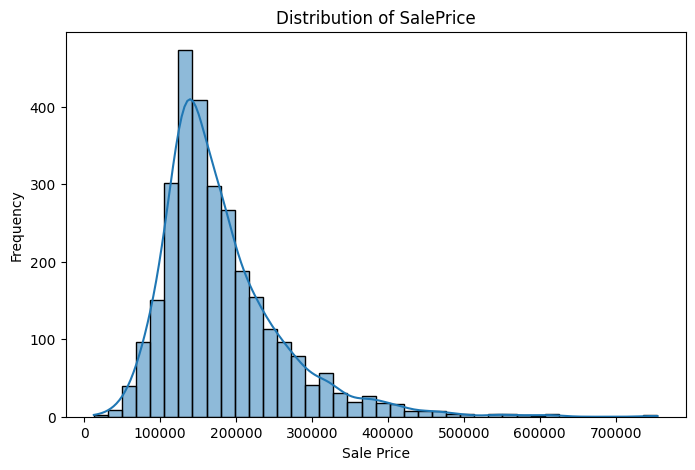

In [14]:
# ============================================
# Target Distribution
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], bins=40, kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

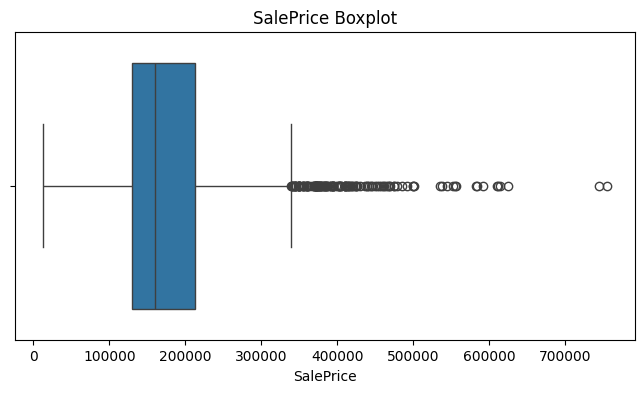

In [15]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["SalePrice"])

plt.title("SalePrice Boxplot")

plt.show()

# Exploratory Data Analysis (EDA)

In [16]:
# ============================================
# Correlation with SalePrice
# ============================================

corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

corr.to_frame().head(20)

,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647877
Garage Area,0.640401
Total Bsmt SF,0.632280
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Year Remod/Add,0.532974


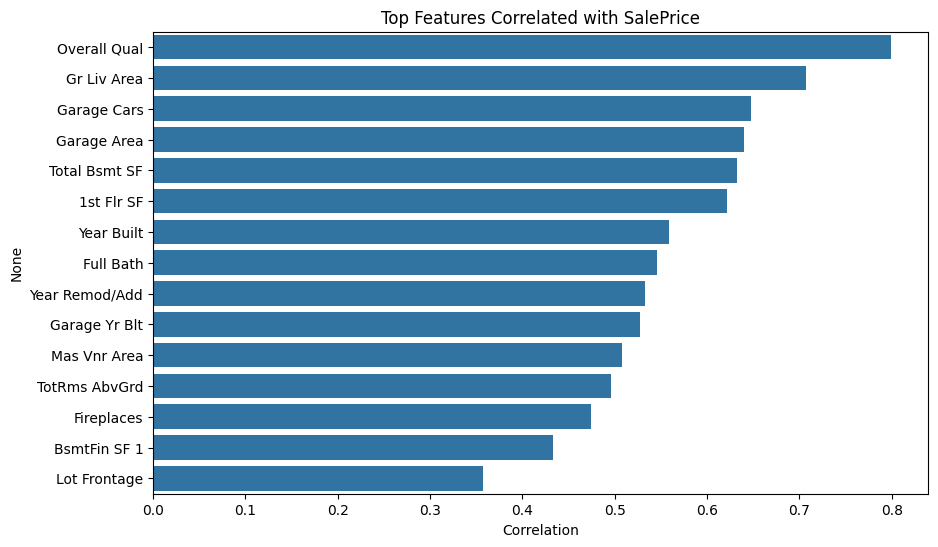

In [17]:
# ============================================
# Top Correlated Features
# ============================================

top_corr = corr.iloc[1:16]

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with SalePrice")

plt.xlabel("Correlation")

plt.show()

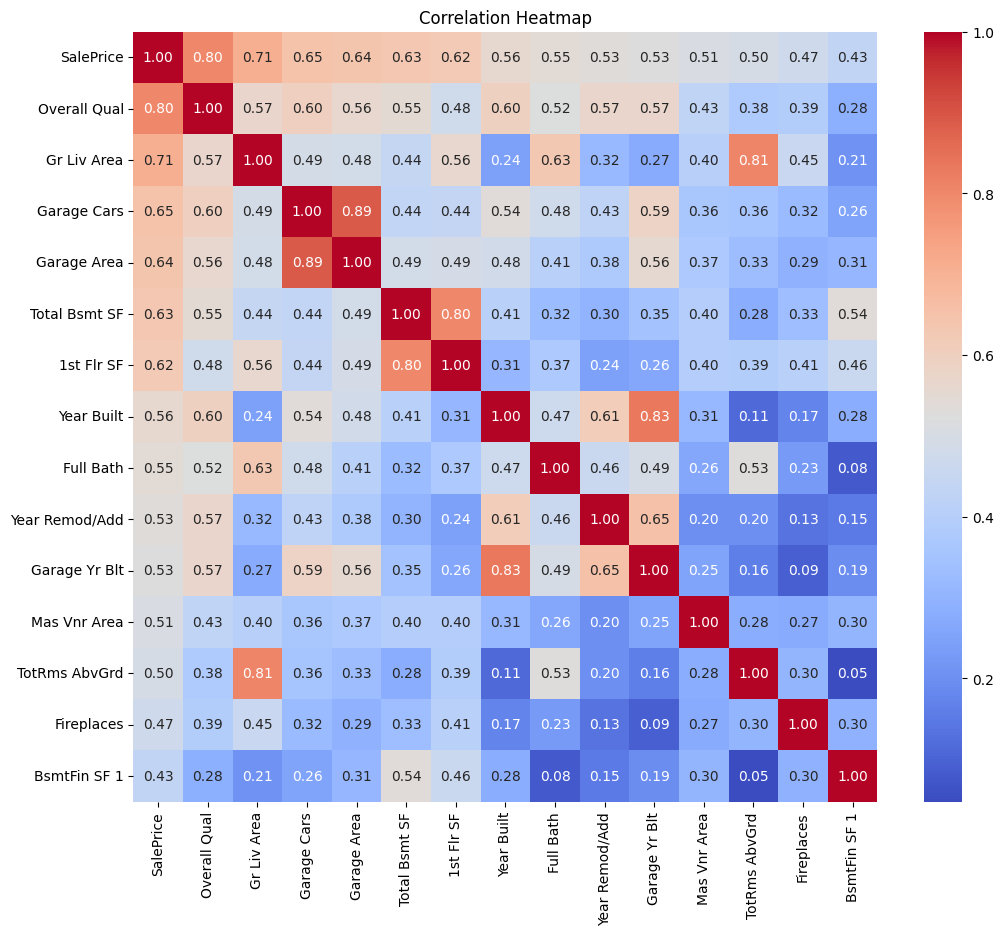

In [18]:
# ============================================
# Correlation Heatmap
# ============================================

top_features = corr.index[:15]

plt.figure(figsize=(12,10))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Data Cleaning

In this section, missing values and unnecessary features are handled based on domain knowledge and dataset characteristics rather than applying generic imputation techniques.

The objective is to preserve as much information as possible while preparing the data for machine learning models.


In [19]:
# ============================================
# Drop Identifier Columns
# ============================================

df = df.drop(columns=["Order", "PID"])

print("Identifier columns removed.")

Identifier columns removed.


In [20]:
# ============================================
# Missing Values
# ============================================

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_df

,Missing Values,Percentage
Pool QC,2917,99.56
Misc Feature,2824,96.38
Alley,2732,93.24
Fence,2358,80.48
Mas Vnr Type,1775,60.58
Fireplace Qu,1422,48.53
Lot Frontage,490,16.72
Garage Qual,159,5.43
Garage Cond,159,5.43
Garage Yr Blt,159,5.43


In [21]:
# ============================================
# Fill Missing Values (Feature Not Present)
# ============================================

none_columns = [
    "Alley",
    "Mas Vnr Type",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Pool QC",
    "Fence",
    "Misc Feature"
]

for col in none_columns:
    if col in df.columns:
        df[col] = df[col].fillna("None")

print("Categorical 'Not Present' values handled.")

Categorical 'Not Present' values handled.


In [22]:
# ============================================
# Fill Numerical Missing Values
# ============================================

median_columns = [
    "Lot Frontage",
    "Mas Vnr Area",
    "Garage Yr Blt"
]

for col in median_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Numerical missing values handled.")

Numerical missing values handled.


In [23]:
# ============================================
# Fill Remaining Categorical Missing Values
# ============================================

remaining_cat = df.select_dtypes(include="object").columns

for col in remaining_cat:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining categorical missing values handled.")

Remaining categorical missing values handled.


In [24]:
# ============================================
# Check Missing Values Again
# ============================================

missing = df.isnull().sum()

missing = missing[missing > 0]

print(f"Columns still containing missing values : {len(missing)}")

missing

Columns still containing missing values : 8


BsmtFin SF 1      1
BsmtFin SF 2      1
Bsmt Unf SF       1
Total Bsmt SF     1
Bsmt Full Bath    2
Bsmt Half Bath    2
Garage Cars       1
Garage Area       1
dtype: int64

In [25]:
# ============================================
# Fill Remaining Numerical Missing Values
# ============================================

zero_fill_columns = [
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Garage Cars",
    "Garage Area"
]

for col in zero_fill_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print("Remaining numerical missing values handled.")

Remaining numerical missing values handled.


In [26]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(f"Columns still containing missing values : {len(missing)}")

missing

Columns still containing missing values : 0


Series([], dtype: int64)

### Handling Numerical Missing Values

Some numerical features still contained missing values after categorical imputation.

These missing values occur because the corresponding house does not contain that feature (for example, no basement or no garage).

Instead of replacing these values with the median, they are filled with **0**, which correctly represents the absence of the feature and preserves the semantic meaning of the data.

# Feature Engineering

Feature engineering involves creating new features from existing ones to improve the predictive power of machine learning models.

Only features with clear business meaning are created in this project.

In [27]:
# ============================================
# House Age
# ============================================

df["HouseAge"] = df["Yr Sold"] - df["Year Built"]

In [28]:
# ============================================
# Years Since Remodel
# ============================================

df["RemodAge"] = df["Yr Sold"] - df["Year Remod/Add"]

In [29]:
# ============================================
# Total Bathrooms
# ============================================

df["TotalBathrooms"] = (
    df["Full Bath"]
    + (0.5 * df["Half Bath"])
    + df["Bsmt Full Bath"]
    + (0.5 * df["Bsmt Half Bath"])
)

In [30]:
# ============================================
# Total Square Feet
# ============================================

df["TotalSF"] = (
    df["Total Bsmt SF"]
    + df["1st Flr SF"]
    + df["2nd Flr SF"]
)

In [31]:
# ============================================
# Total Porch Area
# ============================================

df["TotalPorchSF"] = (
    df["Open Porch SF"]
    + df["Enclosed Porch"]
    + df["3Ssn Porch"]
    + df["Screen Porch"]
)

In [32]:
new_features = [
    "HouseAge",
    "RemodAge",
    "TotalBathrooms",
    "TotalSF",
    "TotalPorchSF"
]

df[new_features].head()

,HouseAge,RemodAge,TotalBathrooms,TotalSF,TotalPorchSF
0,50,50,2.0,2736.0,62
1,49,49,1.0,1778.0,120
2,52,52,1.5,2658.0,36
3,42,42,3.5,4220.0,0
4,13,12,2.5,2557.0,34


# Feature Validation

Before using the engineered features for model training, we validate whether they have a meaningful relationship with the target variable (`SalePrice`).

This helps ensure that only informative features are retained, reducing unnecessary complexity and improving model interpretability.

In [33]:
# ============================================
# Engineered Feature Correlation
# ============================================

engineered_features = [
    "HouseAge",
    "RemodAge",
    "TotalBathrooms",
    "TotalSF",
    "TotalPorchSF"
]

corr_engineered = (
    df[engineered_features + ["SalePrice"]]
    .corr(numeric_only=True)["SalePrice"]
    .sort_values(ascending=False)
)

corr_engineered

SalePrice         1.000000
TotalSF           0.793127
TotalBathrooms    0.636175
TotalPorchSF      0.185263
RemodAge         -0.534940
HouseAge         -0.558907
Name: SalePrice, dtype: float64

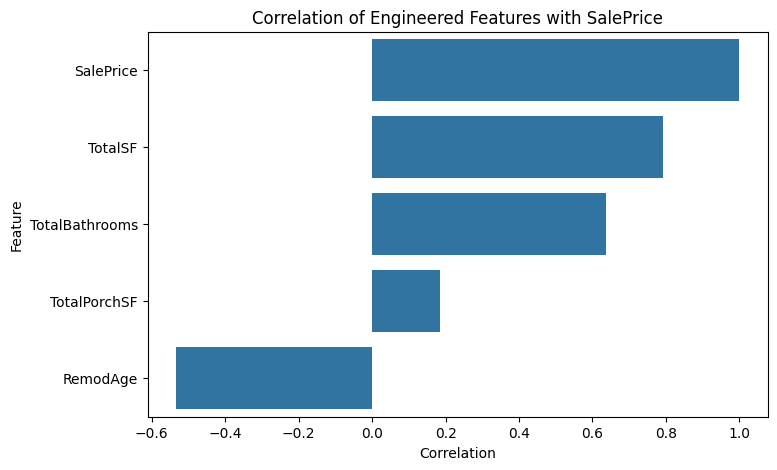

In [34]:
# ============================================
# Correlation Plot
# ============================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=corr_engineered.values[:-1],
    y=corr_engineered.index[:-1]
)

plt.title("Correlation of Engineered Features with SalePrice")

plt.xlabel("Correlation")

plt.ylabel("Feature")

plt.show()

# Prepare Data for Modeling

In this section, the dataset is separated into input features (`X`) and the target variable (`y`).

No preprocessing is applied manually. All transformations will later be handled through a Scikit-learn Pipeline to ensure consistency during training and deployment.

In [35]:
# ============================================
# Features & Target
# ============================================

X = df.drop(columns=["SalePrice"])

y = df["SalePrice"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (2930, 84)
Target Shape         : (2930,)


In [36]:
# ============================================
# Identify Feature Types
# ============================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numerical Features   : {len(numeric_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 41
Categorical Features : 43


In [37]:
# ============================================
# Train Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 2344
Testing Samples  : 586


# Data Preprocessing

Machine learning algorithms require numerical inputs and consistent preprocessing.

To ensure reproducibility and prevent data leakage, all preprocessing steps are implemented using a Scikit-learn Pipeline and ColumnTransformer.

This guarantees that the exact same transformations are applied during both training and prediction.

In [38]:
# ============================================
# Preprocessing Imports
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [39]:
# ============================================
# Numerical Pipeline
# ============================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [40]:
# ============================================
# Categorical Pipeline
# ============================================

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [41]:
# ============================================
# Column Transformer
# ============================================

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Baseline Model Training

Multiple regression algorithms are trained using the same preprocessing pipeline.

This ensures a fair comparison by applying identical preprocessing steps to every model.

In [42]:
# ============================================
# Regression Models
# ============================================

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

In [43]:
# ============================================
# Model Dictionary
# ============================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(random_state=42),

    "Lasso Regression": Lasso(random_state=42),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    )

}

In [44]:
# ============================================
# Model Evaluation Function
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

def evaluate_model(name, model):

    # Build pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R² Score": round(r2, 4)
    })

    print(f"{name} completed.")

In [45]:
# ============================================
# Train All Models
# ============================================

for name, model in models.items():
    evaluate_model(name, model)

Linear Regression completed.
Ridge Regression completed.
Lasso Regression completed.
Decision Tree completed.
Random Forest completed.
Gradient Boosting completed.
XGBoost completed.


In [46]:
# ============================================
# Model Comparison
# ============================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R² Score
0,Gradient Boosting,14776.63,23384.76,0.9318
1,Random Forest,15430.49,25234.15,0.9206
2,XGBoost,15820.33,26974.06,0.9092
3,Ridge Regression,16136.40,28758.56,0.8968
4,Lasso Regression,15630.84,28995.47,0.8951
5,Linear Regression,15658.62,29062.15,0.8947
6,Decision Tree,25339.42,41540.24,0.7848


# Cross Validation

Cross-validation is performed on the top-performing models to evaluate their stability across different subsets of the training data.

Rather than relying on a single train-test split, K-Fold Cross Validation provides a more reliable estimate of model performance and helps reduce the risk of selecting a model due to random chance.

In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

In [48]:
# ============================================
# Cross Validation
# ============================================

def cross_validate_model(name, model):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Fold Scores : {scores}")
    print(f"Mean R²     : {scores.mean():.4f}")
    print(f"Std Dev     : {scores.std():.4f}")
    print()

In [49]:
cross_validate_model(
    "Gradient Boosting",
    GradientBoostingRegressor(random_state=42)
)

cross_validate_model(
    "Random Forest",
    RandomForestRegressor(random_state=42)
)

Gradient Boosting
Fold Scores : [0.92214375 0.93270327 0.90465768 0.86900113 0.93274312]
Mean R²     : 0.9122
Std Dev     : 0.0239

Random Forest
Fold Scores : [0.91111044 0.92305158 0.88623324 0.83583227 0.91079971]
Mean R²     : 0.8934
Std Dev     : 0.0312



# Hyperparameter Tuning

Hyperparameter tuning is performed on the top-performing models to improve predictive performance.

A focused GridSearchCV approach is used to efficiently search the most influential hyperparameters while avoiding unnecessary computational cost.

In [50]:
# ============================================
# Gradient Boosting Pipeline
# ============================================

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [51]:
# ============================================
# Parameter Grid
# ============================================

gb_params = {

    "model__n_estimators": [100, 200],

    "model__learning_rate": [0.05, 0.1],

    "model__max_depth": [3, 4],

    "model__subsample": [0.8, 1.0]

}

In [52]:
# ============================================
# Grid Search
# ============================================

gb_grid = GridSearchCV(

    estimator=gb_pipeline,

    param_grid=gb_params,

    scoring="r2",

    cv=5,

    n_jobs=-1,

    verbose=1

)

gb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 4], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [53]:
print("Best Parameters")
print(gb_grid.best_params_)

print()

print("Best CV Score")
print(gb_grid.best_score_)

Best Parameters
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best CV Score
0.9113408693150848


In [54]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [55]:
rf_params = {

    "model__n_estimators": [100, 200],

    "model__max_depth": [None, 20],

    "model__min_samples_split": [2, 5],

    "model__min_samples_leaf": [1, 2]

}

In [56]:
rf_grid = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=rf_params,

    scoring="r2",

    cv=5,

    n_jobs=-1,

    verbose=1

)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 20], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [57]:
print("Best Parameters")
print(rf_grid.best_params_)

print()

print("Best CV Score")
print(rf_grid.best_score_)

Best Parameters
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV Score
0.8850986303354624


# Final Model Evaluation

The best-performing model selected through cross-validation and hyperparameter tuning is evaluated on the unseen test set.

This provides an unbiased estimate of real-world predictive performance.

In [58]:
# ============================================
# Final Evaluation - Gradient Boosting
# ============================================

best_model = gb_grid.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Final Model Performance")
print("-" * 30)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Final Model Performance
------------------------------
MAE  : 13482.15
RMSE : 22945.03
R²   : 0.9343


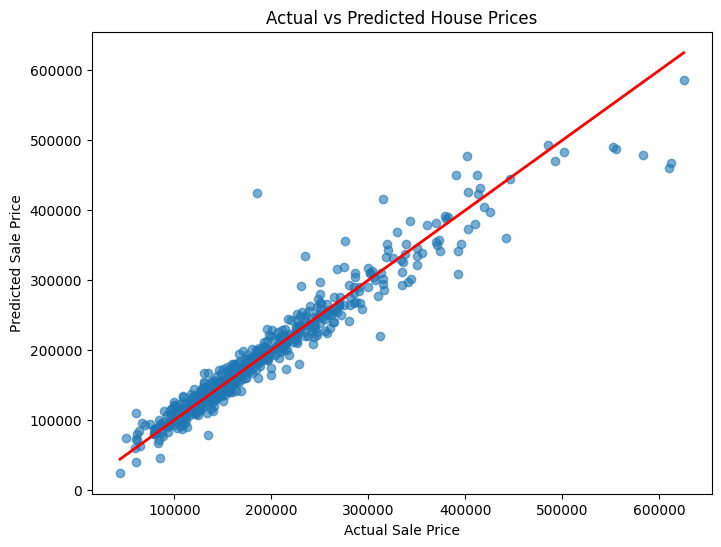

In [59]:
# ============================================
# Actual vs Predicted
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# Feature Importance

Feature importance scores help identify which variables contribute most to predicting house prices, improving the interpretability of the model.

In [60]:
# ============================================
# Feature Names After Preprocessing
# ============================================

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# ============================================
# Feature Importance
# ============================================

importances = best_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(20)

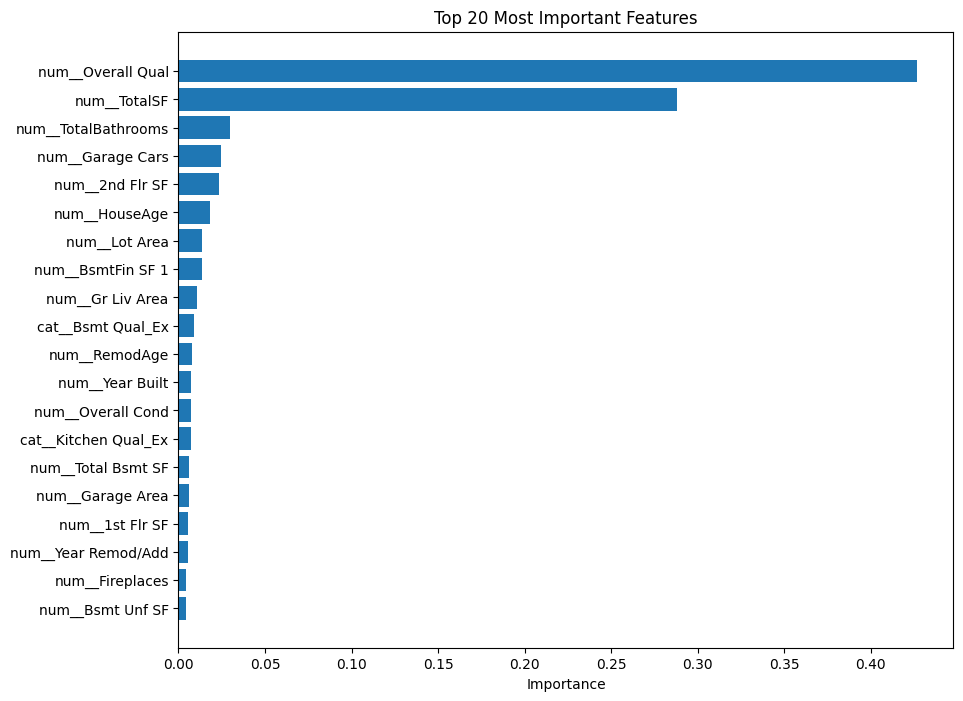

In [62]:
# ============================================
# Top 20 Feature Importances
# ============================================

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 20 Most Important Features")

plt.show()

# Residual Analysis

Residual analysis helps evaluate model performance by examining prediction errors.

A well-performing regression model should produce residuals that are randomly distributed around zero without any obvious patterns.

In [64]:
# ============================================
# Residuals
# ============================================

residuals = y_test - y_pred

residual_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals
})

residual_df.head()

,Actual,Predicted,Residual
1357,161000,179950.316995,-18950.316995
2367,116000,107335.157823,8664.842177
2822,196500,186051.228860,10448.771140
2126,123600,121834.423998,1765.576002
1544,126000,114685.383760,11314.616240


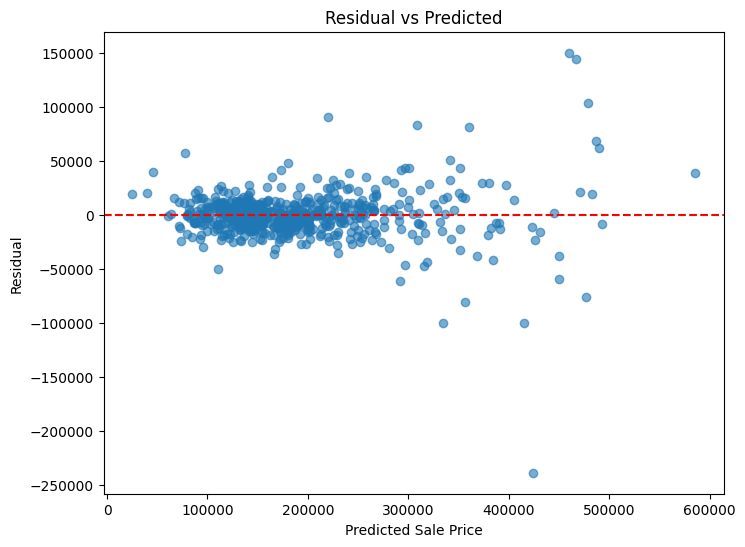

In [65]:
# ============================================
# Residual Plot
# ============================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")

plt.title("Residual vs Predicted")

plt.show()

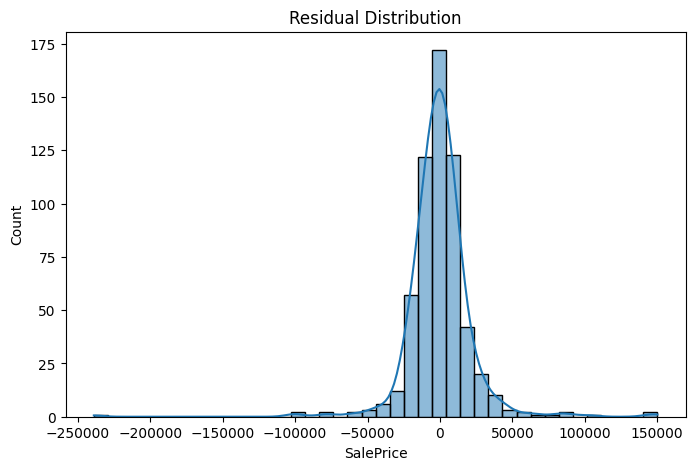

In [66]:
# ============================================
# Residual Distribution
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

# Learning Curve

A learning curve evaluates model performance as the size of the training dataset increases.

It helps identify whether additional training data is likely to improve model performance.

In [67]:
from sklearn.model_selection import learning_curve

In [70]:
# ============================================
# Learning Curve
# ============================================

train_sizes, train_scores, val_scores = learning_curve(

    estimator=best_model,

    X=X_train,

    y=y_train,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    train_sizes=np.linspace(0.1, 1.0, 10)

)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

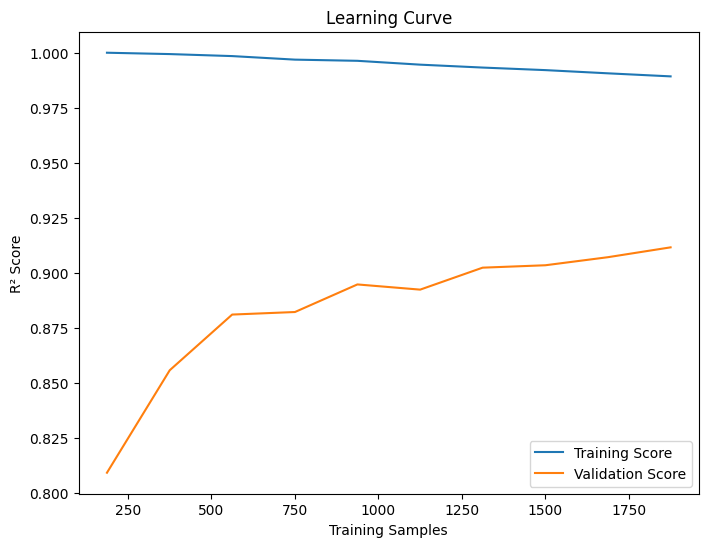

In [69]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training Score")

plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Samples")

plt.ylabel("R² Score")

plt.title("Learning Curve")

plt.legend()

plt.show()

In [87]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

In [88]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
82,TotalSF,0.222807
16,Overall Qual,0.176891
60,Garage Cars,0.014152
3,Lot Area,0.009122
17,Overall Cond,0.007850
66,Open Porch SF,0.006788
81,TotalBathrooms,0.006644
11,Neighborhood,0.005737
43,2nd Flr SF,0.005250
80,RemodAge,0.005070


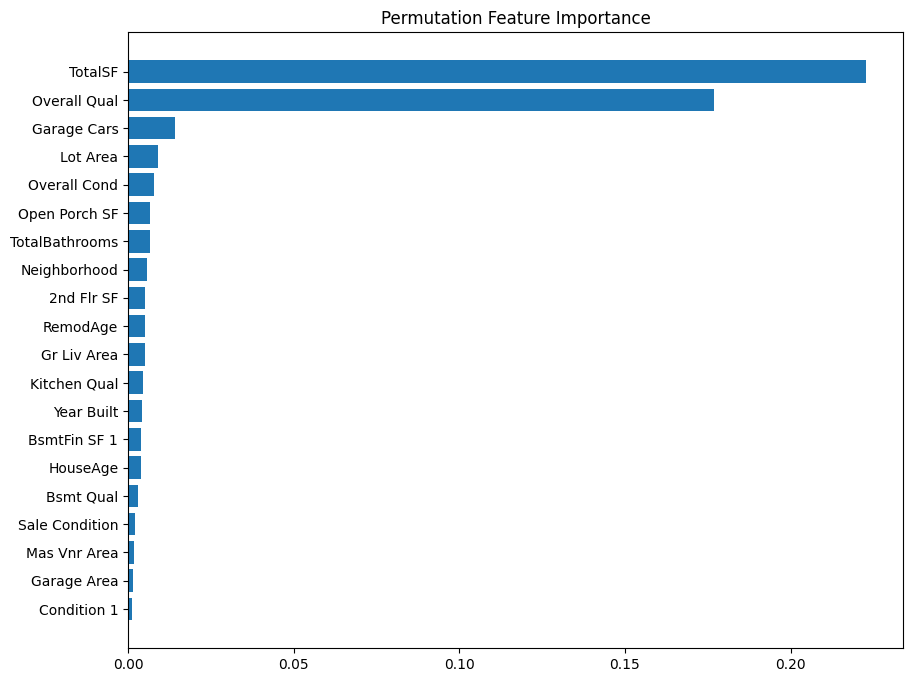

In [89]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance")

plt.show()

# Model Serialization

The final Gradient Boosting pipeline, including preprocessing and the trained model, is saved using Joblib.

Saving the complete pipeline ensures that all preprocessing steps and the trained model are preserved together, allowing consistent predictions during deployment without additional preprocessing code.

In [90]:
import joblib
import os

In [91]:
os.makedirs("../models", exist_ok=True)

In [92]:
os.makedirs("models", exist_ok=True)

In [93]:
joblib.dump(
    best_model,
    "../models/house_price_pipeline.joblib"
)

print("✅ Pipeline saved successfully!")

✅ Pipeline saved successfully!


In [94]:
joblib.dump(
    best_model,
    "models/house_price_pipeline.joblib"
)

print("✅ Pipeline saved successfully!")

✅ Pipeline saved successfully!


In [95]:
import os

print(os.path.exists("../models/house_price_pipeline.joblib"))

True


In [96]:
loaded_model = joblib.load("../models/house_price_pipeline.joblib")

sample_prediction = loaded_model.predict(X_test.iloc[[0]])

print("Prediction:", sample_prediction[0])

Prediction: 179950.3169952262
